In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("df_top5.csv")
df

,Country,League,home_team,away_team,home_score,away_score,season_year,first_half,second_half,home_team_goals_current_time,...,minuto_gol_home,minuto_gol_away,equipo_marco_primero,equipo_ganador,anoto_primero_y_gano,save_ratio_home,save_ratio_away,equipo_mas_faltas,mas_faltas_perdio,gana_quien_mas_amarillas
0,Germany,Bundesliga,B. Monchengladbach,Werder Bremen,4,1,2024/2025,3 - 0,1 - 1,"[""11'"", ""12'"", ""45'"", ""66'""]",...,11.0,75.0,home,home,1,0.800000,0.500000,home,0,False
1,Germany,Bundesliga,Freiburg,Mainz,0,0,2024/2025,0 - 0,0 - 0,NaN,...,NaN,NaN,ninguno,draw,0,1.000000,1.000000,away,1,False
2,Germany,Bundesliga,Dortmund,RB Leipzig,2,1,2024/2025,1 - 1,1 - 0,"[""30'"", ""65'""]",...,30.0,27.0,away,home,0,0.666667,0.714286,away,1,False
3,Germany,Bundesliga,Bayern Munich,Union Berlin,3,0,2024/2025,2 - 0,1 - 0,"[""15'"", ""43'"", ""51'""]",...,15.0,NaN,home,home,1,1.000000,0.571429,away,1,False
4,Germany,Bundesliga,Eintracht Frankfurt,Bochum,7,2,2024/2025,4 - 1,3 - 1,"[""9'"", ""18'"", ""20'"", ""32'"", ""61'"", ""66'"", ""69'""]",...,9.0,35.0,home,home,1,0.750000,0.222222,away,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34980,Spain,Laliga,Valladolid,Rayo Vallecano,1,3,2000/2001,1 - 1,0 - 2,NaN,...,NaN,NaN,ninguno,away,0,NaN,NaN,empate,0,False
34981,Spain,Laliga,Dep. La Coruna,Villarreal,4,2,2000/2001,2 - 0,2 - 2,NaN,...,NaN,NaN,ninguno,home,0,NaN,NaN,empate,0,False
34982,Spain,Laliga,Malaga,Celta Vigo,1,4,2000/2001,1 - 2,0 - 2,NaN,...,NaN,NaN,ninguno,away,0,NaN,NaN,empate,0,False
34983,Spain,Laliga,Real Madrid,Numancia,1,0,2000/2001,1 - 0,0 - 0,NaN,...,NaN,NaN,ninguno,home,0,NaN,NaN,empate,0,False


## EDA

In [3]:
# Miramos de que tipo es cada columna y un vistazo de si hay nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34985 entries, 0 to 34984
Data columns (total 60 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               34985 non-null  object 
 1   League                                34985 non-null  object 
 2   home_team                             34985 non-null  object 
 3   away_team                             34985 non-null  object 
 4   home_score                            34985 non-null  int64  
 5   away_score                            34985 non-null  int64  
 6   season_year                           34985 non-null  object 
 7   first_half                            34853 non-null  object 
 8   second_half                           34875 non-null  object 
 9   home_team_goals_current_time          15234 non-null  object 
 10  home_team_goals                       13129 non-null  object 
 11  home_team_goals

In [4]:
# Miramos cuantos nulos hay y donde.

df.isnull().sum()

Country                                     0
League                                      0
home_team                                   0
away_team                                   0
home_score                                  0
away_score                                  0
season_year                                 0
first_half                                132
second_half                               110
home_team_goals_current_time            19751
home_team_goals                         21856
home_team_goals_assist                  21856
away_team_goals_current_time            21896
away_team_goals                         23477
away_team_goals_assist                  23477
home_team_yellow_card_why               23907
away_team_yellow_card_why               23368
home_team_red_card_why                  33910
away_team_red_card_why                  33730
home_team_substitutions_current_time    19893
home_team_substitutions                 19894
home_team_substitutions_with      

In [5]:
# Miramos un poco como esta el dataset con la media, valores minimos maximos y los percentiles

df.describe()

,home_score,away_score,expected_goals_xg_home,expected_goals_xg_away,Ball_Possession_Home,Ball_Possession_Away,Shots_on_Goal_Home,Shots_on_Goal_Away,Offsides_Home,Offsides_Away,...,Total_Passes_Home,Total_Passes_Away,diferencia_goles,total_goles,minuto_gol_home,minuto_gol_away,anoto_primero_y_gano,save_ratio_home,save_ratio_away,mas_faltas_perdio
count,34985.000000,34985.000000,2667.000000,2667.000000,17407.000000,17407.000000,17407.000000,17407.000000,34985.000000,34985.000000,...,7433.000000,7433.000000,34985.000000,34985.00000,15222.000000,13081.000000,34985.000000,1.686100e+04,1.713500e+04,34985.000000
mean,1.538517,1.172274,1.588361,1.249516,51.115298,48.884874,4.976963,4.097662,1.016750,0.925825,...,462.931656,441.078030,1.346949,2.71079,28.068913,30.189206,0.385108,inf,inf,0.295012
std,1.287976,1.139893,0.908953,0.781945,10.689989,10.689999,2.728617,2.421370,1.569746,1.459752,...,139.237669,127.369141,1.202924,1.67011,23.480301,24.577206,0.486628,NaN,NaN,0.456055
min,0.000000,0.000000,0.000000,0.000000,18.000000,16.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,1.000000,0.000000,0.910000,0.670000,44.000000,41.000000,3.000000,2.000000,0.000000,0.000000,...,367.000000,350.000000,0.000000,2.00000,8.000000,9.000000,0.000000,5.000000e-01,5.000000e-01,0.000000
50%,1.000000,1.000000,1.430000,1.120000,51.000000,49.000000,5.000000,4.000000,0.000000,0.000000,...,449.000000,428.000000,1.000000,3.00000,22.000000,24.000000,0.000000,7.142857e-01,6.666667e-01,0.000000
75%,2.000000,2.000000,2.140000,1.660000,59.000000,56.000000,7.000000,6.000000,2.000000,2.000000,...,547.000000,520.000000,2.000000,4.00000,43.000000,48.000000,1.000000,1.000000e+00,8.571429e-01,1.000000
max,9.000000,9.000000,7.200000,4.550000,84.000000,82.000000,22.000000,20.000000,12.000000,12.000000,...,3411.000000,975.000000,9.000000,11.00000,90.000000,90.000000,1.000000,inf,inf,1.000000


In [6]:
# Local win = 1, else = 0 (empate o victoria visitante)
df['resultado_bin'] = df['resultado'].apply(lambda x: 1 if x == 'local' else 0)


In [27]:
df

,Country,League,home_team,away_team,home_score,away_score,season_year,first_half,second_half,home_team_goals_current_time,...,anoto_primero_y_gano,save_ratio_home,save_ratio_away,equipo_mas_faltas,mas_faltas_perdio,gana_quien_mas_amarillas,resultado_bin,posesion_bin,xg_bin,resultado_encoded
0,Germany,Bundesliga,B. Monchengladbach,Werder Bremen,4,1,2024/2025,3 - 0,1 - 1,"[""11'"", ""12'"", ""45'"", ""66'""]",...,1,0.800000,0.500000,home,0,False,1,"(40.0, 50.0]","(2.0, 2.5]",1
1,Germany,Bundesliga,Freiburg,Mainz,0,0,2024/2025,0 - 0,0 - 0,NaN,...,0,1.000000,1.000000,away,1,False,0,"(50.0, 60.0]","(0.5, 1.0]",0
2,Germany,Bundesliga,Dortmund,RB Leipzig,2,1,2024/2025,1 - 1,1 - 0,"[""30'"", ""65'""]",...,0,0.666667,0.714286,away,1,False,1,"(50.0, 60.0]","(2.5, 3.0]",1
3,Germany,Bundesliga,Bayern Munich,Union Berlin,3,0,2024/2025,2 - 0,1 - 0,"[""15'"", ""43'"", ""51'""]",...,1,1.000000,0.571429,away,1,False,1,"(70.0, 80.0]","(2.0, 2.5]",1
4,Germany,Bundesliga,Eintracht Frankfurt,Bochum,7,2,2024/2025,4 - 1,3 - 1,"[""9'"", ""18'"", ""20'"", ""32'"", ""61'"", ""66'"", ""69'""]",...,1,0.750000,0.222222,away,1,False,1,"(60.0, 70.0]","(1.5, 2.0]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34968,Spain,Laliga,Valladolid,Rayo Vallecano,1,3,2000/2001,1 - 1,0 - 2,NaN,...,0,0.142857,0.750000,empate,0,False,0,NaN,NaN,2
34969,Spain,Laliga,Dep. La Coruna,Villarreal,4,2,2000/2001,2 - 0,2 - 2,NaN,...,0,0.500000,0.200000,empate,0,False,1,NaN,NaN,1
34970,Spain,Laliga,Malaga,Celta Vigo,1,4,2000/2001,1 - 2,0 - 2,NaN,...,0,0.000000,0.800000,empate,0,False,0,NaN,NaN,2
34971,Spain,Laliga,Real Madrid,Numancia,1,0,2000/2001,1 - 0,0 - 0,NaN,...,0,1.000000,0.857143,empate,0,False,1,NaN,NaN,1


In [7]:
columnas_relevantes = [
    'expected_goals_xg_home', 'expected_goals_xg_away',
    'Ball_Possession_Home', 'Ball_Possession_Away',
    'Shots_on_Goal_Home', 'Shots_on_Goal_Away',
    'Goalkeeper_Saves_Home', 'Goalkeeper_Saves_Away',
    'Fouls_Home', 'Fouls_Away',
    'Red_Cards_Home', 'Red_Cards_Away',
    'Yellow_Cards_Home', 'Yellow_Cards_Away',
    'Offsides_Home', 'Offsides_Away',
    'resultado_bin'
]


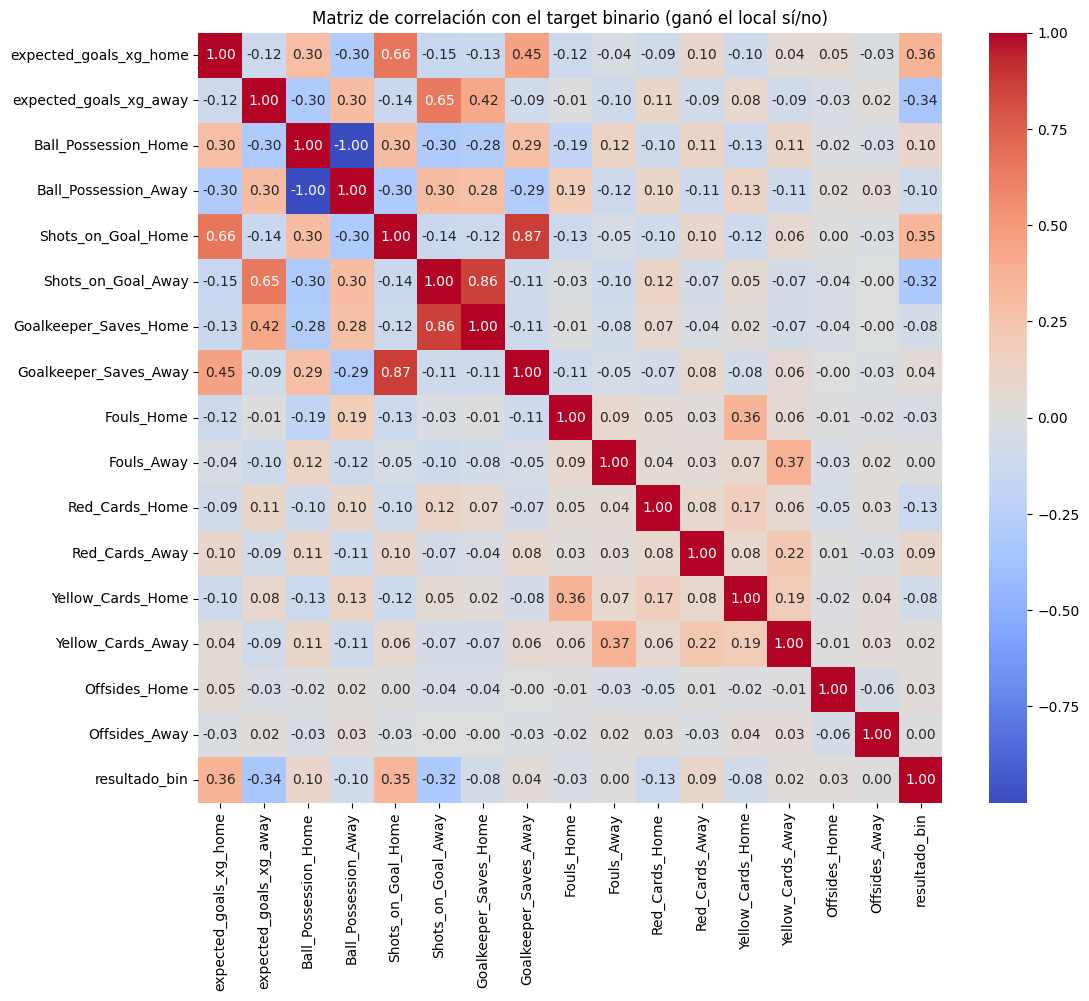

In [8]:
# Asegurarse de que todo sea numérico y no haya NaNs molestos
cols_corr = columnas_relevantes[:-1] + ['resultado_bin']
df_corr = df[cols_corr].dropna()

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación con el target binario (ganó el local sí/no)")
plt.show()


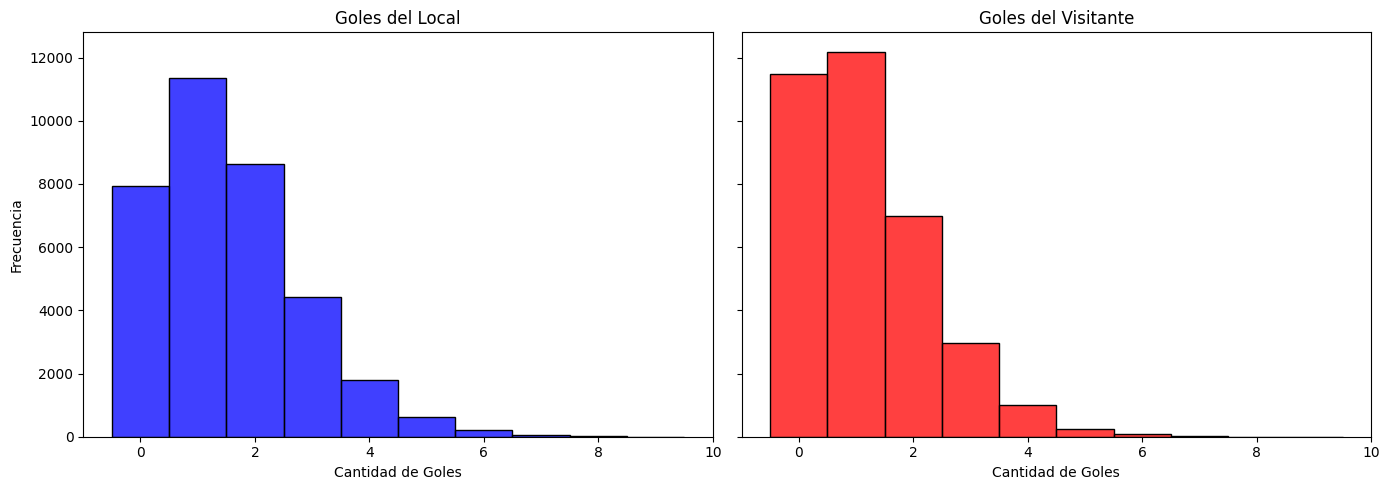

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(df['home_score'], bins=range(0, 9), kde=False, color='blue', ax=axes[0], discrete=True)
axes[0].set_title('Goles del Local')
axes[0].set_xlabel('Cantidad de Goles')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['away_score'], bins=range(0, 9), kde=False, color='red', ax=axes[1], discrete=True)
axes[1].set_title('Goles del Visitante')
axes[1].set_xlabel('Cantidad de Goles')

plt.tight_layout()
plt.show()


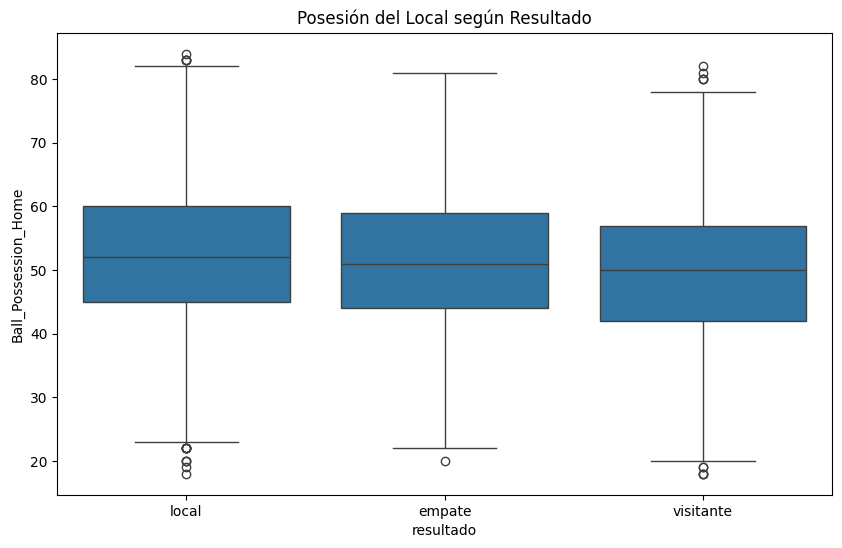

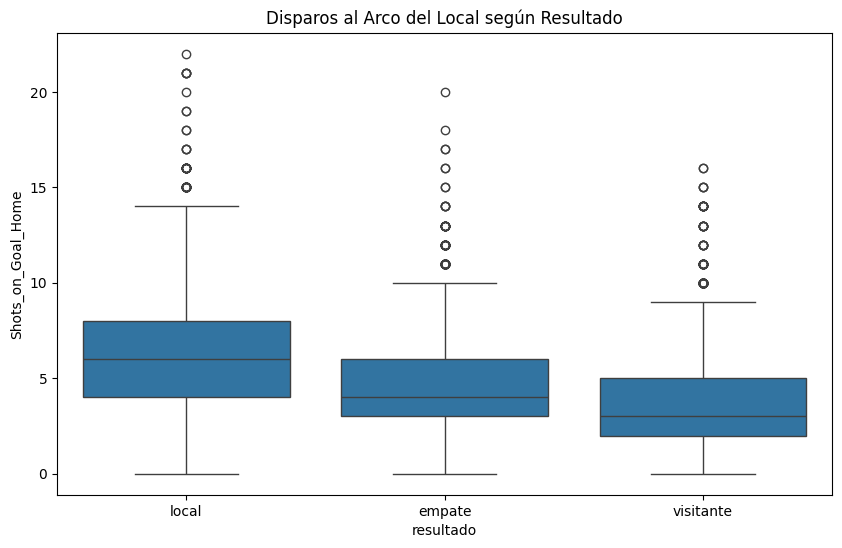

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(x='resultado', y='Ball_Possession_Home', data=df)
plt.title('Posesión del Local según Resultado')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='resultado', y='Shots_on_Goal_Home', data=df)
plt.title('Disparos al Arco del Local según Resultado')
plt.show()


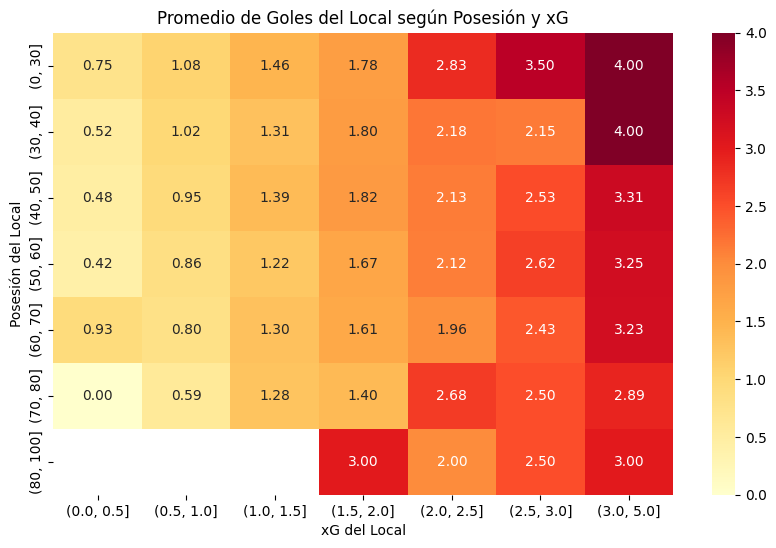

In [11]:
# Crear columnas binned
df['posesion_bin'] = pd.cut(df['Ball_Possession_Home'], bins=[0, 30, 40, 50, 60, 70, 80, 100])
df['xg_bin'] = pd.cut(df['expected_goals_xg_home'], bins=[0, 0.5, 1, 1.5, 2, 2.5, 3, 5])

# Agrupar por bins y calcular promedio de goles
pivot = df.pivot_table(values='home_score', index='posesion_bin', columns='xg_bin', aggfunc='mean')

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title('Promedio de Goles del Local según Posesión y xG')
plt.ylabel('Posesión del Local')
plt.xlabel('xG del Local')
plt.show()


## Feature Engiengineering

In [12]:
# Encodeo de variables categóricas si las hay
le = LabelEncoder()
df['resultado_encoded'] = le.fit_transform(df['resultado'])  # Para usar como target


### Sacar medianas de Xg de cada equipos dependiendo su localia.

In [13]:
# Calcular medianas por equipo y localía
medianas_local = df.groupby('home_team')['expected_goals_xg_home'].median()
medianas_visitante = df.groupby('away_team')['expected_goals_xg_away'].median()

# Calcular mediana general solo si ambas columnas existen (para el mismo equipo)
# Ejemplo: Arsenal local + visitante → Arsenal general
df['all_xg_local'] = df['expected_goals_xg_home']
df['all_xg_visitante'] = df['expected_goals_xg_away']

general_local = df[['home_team', 'all_xg_local']].rename(columns={'home_team': 'team'}).groupby('team')['all_xg_local'].median()
general_visitante = df[['away_team', 'all_xg_visitante']].rename(columns={'away_team': 'team'}).groupby('team')['all_xg_visitante'].median()

# Función para rellenar home
def fill_xg_home(row):
    if pd.notnull(row['expected_goals_xg_home']):
        return row['expected_goals_xg_home']
    team = row['home_team']
    if team in medianas_local and not np.isnan(medianas_local[team]):
        return medianas_local[team]
    if team in general_local and not np.isnan(general_local[team]):
        return general_local[team]
    return df['expected_goals_xg_home'].median()

# Función para rellenar away
def fill_xg_away(row):
    if pd.notnull(row['expected_goals_xg_away']):
        return row['expected_goals_xg_away']
    team = row['away_team']
    if team in medianas_visitante and not np.isnan(medianas_visitante[team]):
        return medianas_visitante[team]
    if team in general_visitante and not np.isnan(general_visitante[team]):
        return general_visitante[team]
    return df['expected_goals_xg_away'].median()

# Aplicar funciones
df['expected_goals_xg_home'] = df.apply(fill_xg_home, axis=1)
df['expected_goals_xg_away'] = df.apply(fill_xg_away, axis=1)

# Limpiar columnas temporales
df.drop(columns=['all_xg_local', 'all_xg_visitante'], inplace=True)


### Sacar medianas de posesión de balon de cada equipos dependiendo su localia.

In [14]:
# Calcular medianas por equipo local/visitante
medianas_pos_local = df.groupby('home_team')['Ball_Possession_Home'].median()
medianas_pos_visitante = df.groupby('away_team')['Ball_Possession_Away'].median()

# Calcular mediana general del equipo (local + visitante)
df['all_pos_home'] = df['Ball_Possession_Home']
df['all_pos_away'] = df['Ball_Possession_Away']

general_pos_home = df[['home_team', 'all_pos_home']].rename(columns={'home_team': 'team'}).groupby('team')['all_pos_home'].median()
general_pos_away = df[['away_team', 'all_pos_away']].rename(columns={'away_team': 'team'}).groupby('team')['all_pos_away'].median()

# Calcular mediana global solo para partidos local/visitante
global_pos_home = df['Ball_Possession_Home'].median()
global_pos_away = df['Ball_Possession_Away'].median()

# Función para rellenar home
def fill_pos_home(row):
    if pd.notnull(row['Ball_Possession_Home']):
        return row['Ball_Possession_Home']
    team = row['home_team']
    if team in medianas_pos_local and not np.isnan(medianas_pos_local[team]):
        return medianas_pos_local[team]
    if team in general_pos_home and not np.isnan(general_pos_home[team]):
        return general_pos_home[team]
    return global_pos_home

# Función para rellenar away
def fill_pos_away(row):
    if pd.notnull(row['Ball_Possession_Away']):
        return row['Ball_Possession_Away']
    team = row['away_team']
    if team in medianas_pos_visitante and not np.isnan(medianas_pos_visitante[team]):
        return medianas_pos_visitante[team]
    if team in general_pos_away and not np.isnan(general_pos_away[team]):
        return general_pos_away[team]
    return global_pos_away

# Aplicar
df['Ball_Possession_Home'] = df.apply(fill_pos_home, axis=1)
df['Ball_Possession_Away'] = df.apply(fill_pos_away, axis=1)

# Limpiar columnas temporales
df.drop(columns=['all_pos_home', 'all_pos_away'], inplace=True)


### Sacar paradas del portero.

In [15]:
# Calcular medianas por equipo y localía
medianas_shots_local = df.groupby('home_team')['Shots_on_Goal_Home'].median()
medianas_shots_visitante = df.groupby('away_team')['Shots_on_Goal_Away'].median()

# Calcular mediana general por equipo
df['all_shots'] = df[['Shots_on_Goal_Home', 'Shots_on_Goal_Away']].mean(axis=1)
medianas_shots_equipo = pd.concat([
    df[['home_team', 'all_shots']].rename(columns={'home_team': 'team'}),
    df[['away_team', 'all_shots']].rename(columns={'away_team': 'team'})
]).groupby('team')['all_shots'].median()

# Función para rellenar Shots_on_Goal_Home
def fill_shots_home(row):
    if pd.notnull(row['Shots_on_Goal_Home']):
        return row['Shots_on_Goal_Home']
    team = row['home_team']
    if team in medianas_shots_local and not np.isnan(medianas_shots_local[team]):
        return medianas_shots_local[team]
    if team in medianas_shots_equipo and not np.isnan(medianas_shots_equipo[team]):
        return medianas_shots_equipo[team]
    return df['Shots_on_Goal_Home'].median()

# Función para rellenar Shots_on_Goal_Away
def fill_shots_away(row):
    if pd.notnull(row['Shots_on_Goal_Away']):
        return row['Shots_on_Goal_Away']
    team = row['away_team']
    if team in medianas_shots_visitante and not np.isnan(medianas_shots_visitante[team]):
        return medianas_shots_visitante[team]
    if team in medianas_shots_equipo and not np.isnan(medianas_shots_equipo[team]):
        return medianas_shots_equipo[team]
    return df['Shots_on_Goal_Away'].median()

# Aplicar funciones
df['Shots_on_Goal_Home'] = df.apply(fill_shots_home, axis=1)
df['Shots_on_Goal_Away'] = df.apply(fill_shots_away, axis=1)

# Limpiar columna temporal
df.drop(columns=['all_shots'], inplace=True)


In [16]:
# Paradas portero local (portero del home → calcula usando tiros del away)
df['Goalkeeper_Saves_Home'] = df.apply(
    lambda row: max(row['Shots_on_Goal_Away'] - row['away_score'], 0)
    if pd.isna(row['Goalkeeper_Saves_Home']) and 
       pd.notnull(row['Shots_on_Goal_Away']) and 
       pd.notnull(row['away_score'])
    else row['Goalkeeper_Saves_Home'],
    axis=1
)

# Paradas portero visitante (portero del away → calcula usando tiros del home)
df['Goalkeeper_Saves_Away'] = df.apply(
    lambda row: max(row['Shots_on_Goal_Home'] - row['home_score'], 0)
    if pd.isna(row['Goalkeeper_Saves_Away']) and 
       pd.notnull(row['Shots_on_Goal_Home']) and 
       pd.notnull(row['home_score'])
    else row['Goalkeeper_Saves_Away'],
    axis=1
)

In [17]:
# Recalcular save_ratio de forma segura
df['save_ratio_home'] = df.apply(
    lambda row: row['Goalkeeper_Saves_Home'] / row['Shots_on_Goal_Away']
    if pd.notnull(row['Goalkeeper_Saves_Home']) and 
       pd.notnull(row['Shots_on_Goal_Away']) and 
       row['Shots_on_Goal_Away'] > 0
    else 0,
    axis=1
)

df['save_ratio_away'] = df.apply(
    lambda row: row['Goalkeeper_Saves_Away'] / row['Shots_on_Goal_Home']
    if pd.notnull(row['Goalkeeper_Saves_Away']) and 
       pd.notnull(row['Shots_on_Goal_Home']) and 
       row['Shots_on_Goal_Home'] > 0
    else 0,
    axis=1
)

In [18]:
# Nos quitamos las columnas donde Goalkeeper_Saves_X es mayor que Shots_on_Goal_X

df = df[
    (df['Goalkeeper_Saves_Home'] <= df['Shots_on_Goal_Away']) &
    (df['Goalkeeper_Saves_Away'] <= df['Shots_on_Goal_Home'])
].reset_index(drop=True)


In [19]:
# Para ver los partidos con más de 600 pases del equipo local
df[df['Total_Passes_Home'] > 950]



,Country,League,home_team,away_team,home_score,away_score,season_year,first_half,second_half,home_team_goals_current_time,...,anoto_primero_y_gano,save_ratio_home,save_ratio_away,equipo_mas_faltas,mas_faltas_perdio,gana_quien_mas_amarillas,resultado_bin,posesion_bin,xg_bin,resultado_encoded
654,Germany,Bundesliga,Eintracht Frankfurt,RB Leipzig,4,0,2022/2023,2 - 0,2 - 0,"[""16'"", ""22'"", ""67'"", ""84'""]",...,1,0.0,0.555556,home,0,False,1,"(40, 50]",NaN,1
1641,Germany,Bundesliga,Bayer Leverkusen,Eintracht Frankfurt,6,1,2018/2019,6 - 1,0 - 0,"[""2'"", ""13'"", ""23'"", ""28'"", ""34'"", ""36'""]",...,1,0.5,0.454545,away,1,False,1,"(80, 100]",NaN,1
1732,Germany,Bundesliga,Bayer Leverkusen,Dusseldorf,2,0,2018/2019,1 - 0,1 - 0,"[""18'"", ""66'""]",...,1,0.0,0.714286,away,1,False,1,"(80, 100]",NaN,1
7715,France,Ligue-1,PSG,Lorient,0,0,2023/2024,0 - 0,0 - 0,NaN,...,0,0.0,1.000000,home,1,False,0,"(70, 80]","(0.5, 1.0]",0
14472,England,Premier-league,Manchester City,Sheffield Utd,2,0,2023/2024,1 - 0,1 - 0,"[""14'"", ""61'""]",...,1,1.0,0.500000,away,1,False,1,"(80, 100]","(2.0, 2.5]",1
15974,England,Premier-league,Liverpool,Sheffield Utd,2,0,2019/2020,1 - 0,1 - 0,"[""4'"", ""64'""]",...,1,1.0,0.714286,away,1,False,1,"(70, 80]",NaN,1
16093,England,Premier-league,Sheffield Utd,Arsenal,1,0,2019/2020,1 - 0,0 - 0,"[""30'""]",...,1,1.0,0.500000,away,1,False,1,"(30, 40]",NaN,1
16599,England,Premier-league,Manchester City,Swansea,5,0,2017/2018,2 - 0,3 - 0,"[""12'"", ""16'"", ""54'"", ""64'"", ""88'""]",...,1,1.0,0.583333,away,1,False,1,"(80, 100]",NaN,1
16653,England,Premier-league,Manchester City,Chelsea,1,0,2017/2018,0 - 0,1 - 0,"[""46'""]",...,1,0.0,0.666667,away,1,True,1,"(70, 80]",NaN,1


In [20]:
# Para ver los partidos con más de 600 pases del equipo visitante
df[df['Total_Passes_Away'] > 950]

,Country,League,home_team,away_team,home_score,away_score,season_year,first_half,second_half,home_team_goals_current_time,...,anoto_primero_y_gano,save_ratio_home,save_ratio_away,equipo_mas_faltas,mas_faltas_perdio,gana_quien_mas_amarillas,resultado_bin,posesion_bin,xg_bin,resultado_encoded
16630,England,Premier-league,Everton,Manchester City,1,3,2017/2018,0 - 3,1 - 0,"[""63'""]",...,1,0.25,0.5,home,1,False,0,"(0, 30]",NaN,2


In [21]:
df.loc[df['Total_Passes_Home'] == 3411.0, 'Total_Passes_Home'] = 460
df.loc[df['Total_Passes_Home'] == 2288.0, 'Total_Passes_Home'] = 287
df.loc[(df['Total_Passes_Home'] == 1000.0), 'Total_Passes_Home'] = 938
df.loc[df['Total_Passes_Home'] == 1015.0, 'Total_Passes_Home'] = 942
df.loc[df['Total_Passes_Home'] == 976.0,  'Total_Passes_Home'] = 902


###  Rellenar offsides con la mediana y localia

In [22]:
# Calcular medianas
medianas_offsides_local = df.groupby('home_team')['Offsides_Home'].median()
medianas_offsides_visitante = df.groupby('away_team')['Offsides_Away'].median()

df['all_offsides_home'] = df['Offsides_Home']
df['all_offsides_away'] = df['Offsides_Away']

general_offsides_home = df[['home_team', 'all_offsides_home']].rename(columns={'home_team': 'team'}).groupby('team')['all_offsides_home'].median()
general_offsides_away = df[['away_team', 'all_offsides_away']].rename(columns={'away_team': 'team'}).groupby('team')['all_offsides_away'].median()

# Funciones
def fill_offsides_home(row):
    if pd.notnull(row['Offsides_Home']):
        return row['Offsides_Home']
    team = row['home_team']
    if team in medianas_offsides_local:
        return medianas_offsides_local[team]
    if team in general_offsides_home:
        return general_offsides_home[team]
    return df['Offsides_Home'].median()

def fill_offsides_away(row):
    if pd.notnull(row['Offsides_Away']):
        return row['Offsides_Away']
    team = row['away_team']
    if team in medianas_offsides_visitante:
        return medianas_offsides_visitante[team]
    if team in general_offsides_away:
        return general_offsides_away[team]
    return df['Offsides_Away'].median()

# Aplicar
df['Offsides_Home'] = df.apply(fill_offsides_home, axis=1)
df['Offsides_Away'] = df.apply(fill_offsides_away, axis=1)

# Limpiar
df.drop(columns=['all_offsides_home', 'all_offsides_away'], inplace=True)


### Rellenar total de pases con mediana y localia

In [23]:
# Calcular medianas por equipo y general
medianas_passes_local = df.groupby('home_team')['Total_Passes_Home'].median().dropna()
medianas_passes_visitante = df.groupby('away_team')['Total_Passes_Away'].median().dropna()

df['all_passes_home'] = df['Total_Passes_Home']
df['all_passes_away'] = df['Total_Passes_Away']

general_passes_home = df[['home_team', 'all_passes_home']].rename(columns={'home_team': 'team'}).groupby('team')['all_passes_home'].median().dropna()
general_passes_away = df[['away_team', 'all_passes_away']].rename(columns={'away_team': 'team'}).groupby('team')['all_passes_away'].median().dropna()

# Mediana global SOLO de equipos que jugaron de local / visitante
global_home_only_median = df['Total_Passes_Home'].dropna().median()
global_away_only_median = df['Total_Passes_Away'].dropna().median()

# Funciones con prioridad: local → general equipo → mediana local global
def fill_passes_home(row):
    if pd.notnull(row['Total_Passes_Home']):
        return row['Total_Passes_Home']
    team = row['home_team']
    val = medianas_passes_local.get(team)
    if pd.notnull(val):
        return val
    val = general_passes_home.get(team)
    if pd.notnull(val):
        return val
    return global_home_only_median

def fill_passes_away(row):
    if pd.notnull(row['Total_Passes_Away']):
        return row['Total_Passes_Away']
    team = row['away_team']
    val = medianas_passes_visitante.get(team)
    if pd.notnull(val):
        return val
    val = general_passes_away.get(team)
    if pd.notnull(val):
        return val
    return global_away_only_median

# Aplicar
df['Total_Passes_Home'] = df.apply(fill_passes_home, axis=1)
df['Total_Passes_Away'] = df.apply(fill_passes_away, axis=1)

# Limpiar
df.drop(columns=['all_passes_home', 'all_passes_away'], inplace=True)



In [24]:
df

,Country,League,home_team,away_team,home_score,away_score,season_year,first_half,second_half,home_team_goals_current_time,...,anoto_primero_y_gano,save_ratio_home,save_ratio_away,equipo_mas_faltas,mas_faltas_perdio,gana_quien_mas_amarillas,resultado_bin,posesion_bin,xg_bin,resultado_encoded
0,Germany,Bundesliga,B. Monchengladbach,Werder Bremen,4,1,2024/2025,3 - 0,1 - 1,"[""11'"", ""12'"", ""45'"", ""66'""]",...,1,0.800000,0.500000,home,0,False,1,"(40.0, 50.0]","(2.0, 2.5]",1
1,Germany,Bundesliga,Freiburg,Mainz,0,0,2024/2025,0 - 0,0 - 0,NaN,...,0,1.000000,1.000000,away,1,False,0,"(50.0, 60.0]","(0.5, 1.0]",0
2,Germany,Bundesliga,Dortmund,RB Leipzig,2,1,2024/2025,1 - 1,1 - 0,"[""30'"", ""65'""]",...,0,0.666667,0.714286,away,1,False,1,"(50.0, 60.0]","(2.5, 3.0]",1
3,Germany,Bundesliga,Bayern Munich,Union Berlin,3,0,2024/2025,2 - 0,1 - 0,"[""15'"", ""43'"", ""51'""]",...,1,1.000000,0.571429,away,1,False,1,"(70.0, 80.0]","(2.0, 2.5]",1
4,Germany,Bundesliga,Eintracht Frankfurt,Bochum,7,2,2024/2025,4 - 1,3 - 1,"[""9'"", ""18'"", ""20'"", ""32'"", ""61'"", ""66'"", ""69'""]",...,1,0.750000,0.222222,away,1,False,1,"(60.0, 70.0]","(1.5, 2.0]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34968,Spain,Laliga,Valladolid,Rayo Vallecano,1,3,2000/2001,1 - 1,0 - 2,NaN,...,0,0.142857,0.750000,empate,0,False,0,NaN,NaN,2
34969,Spain,Laliga,Dep. La Coruna,Villarreal,4,2,2000/2001,2 - 0,2 - 2,NaN,...,0,0.500000,0.200000,empate,0,False,1,NaN,NaN,1
34970,Spain,Laliga,Malaga,Celta Vigo,1,4,2000/2001,1 - 2,0 - 2,NaN,...,0,0.000000,0.800000,empate,0,False,0,NaN,NaN,2
34971,Spain,Laliga,Real Madrid,Numancia,1,0,2000/2001,1 - 0,0 - 0,NaN,...,0,1.000000,0.857143,empate,0,False,1,NaN,NaN,1


In [25]:
# Definir X, y
x = df[['Ball_Possession_Home', 'Ball_Possession_Away', 'Shots_on_Goal_Home', 'Shots_on_Goal_Away', 'Fouls_Home', 'Fouls_Away',
        'Yellow_Cards_Home', 'Yellow_Cards_Away', 'Red_Cards_Home', 'Red_Cards_Away', 'expected_goals_xg_home', 'expected_goals_xg_away',
        'Goalkeeper_Saves_Home', 'Goalkeeper_Saves_Away', 'Offsides_Home', 'Offsides_Away','Total_Passes_Home', 'Total_Passes_Away',
        'save_ratio_home', 'save_ratio_away']]

y = df['resultado_encoded']

# # Codificar target
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


### Modelos

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Crear pipeline con escalado + modelo
model_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
)

# Entrenar
model_lr.fit(x_train, y_train)

# Predecir
y_pred_lr = model_lr.predict(x_test)

# Mostrar resultados
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))


Matriz de confusión:
[[1764   41   10]
 [  21 3192    4]
 [  23    8 1932]]

Reporte de clasificación:
              precision    recall  f1-score   support

      empate       0.98      0.97      0.97      1815
       local       0.98      0.99      0.99      3217
   visitante       0.99      0.98      0.99      1963

    accuracy                           0.98      6995
   macro avg       0.98      0.98      0.98      6995
weighted avg       0.98      0.98      0.98      6995

